In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [5]:
len(df)

18000

In [6]:
model_hardening_data = df.head(6000)
intercepted_data = df.tail(12000)

In [10]:
model_hardening_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
5995,odroid1,166.0,170.0,167.0,169.0,166.0,168.0,168.0
5996,odroid2,180.0,172.0,156.0,172.0,170.0,12.0,166.0
5997,odroid4,170.0,175.0,175.0,173.0,174.0,175.0,173.0
5998,rpi-4a,620.7,400.1,19.8,18.2,21.0,18.9,19.9


In [11]:
intercepted_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
6000,odroid4,173.0,172.0,174.0,174.0,171.0,172.0,173.0
6001,odroid3,165.0,167.0,168.0,166.0,167.0,167.0,164.0
6002,odroid4,170.0,174.0,173.0,173.0,174.0,173.0,171.0
6003,rpi-8d,16.1,17.8,17.4,781.8,17.6,19.1,19.1
6004,odroid4,172.0,173.0,175.0,174.0,174.0,174.0,175.0
...,...,...,...,...,...,...,...,...
17995,rpi-8a,230.7,231.9,433.3,16.6,232.2,233.2,433.4
17996,odroid1,166.0,169.0,168.0,167.0,168.0,167.0,169.0
17997,odroid1,329.0,169.0,168.0,168.0,167.0,167.0,168.0
17998,rpi-8a,416.6,229.9,16.2,216.5,416.5,233.2,433.5


In [12]:
predictor = TabularPredictor.load("../models/classification")

In [7]:
metadata = Metadata.detect_from_dataframe(
    data=intercepted_data,
    table_name='intercepted_data')

# Which epoch performs the best?

### This takes a very long time (2hrs with an RTX A5000), make sure you have a GPU or adjust epoch interals

In [43]:
# vae_results = pd.DataFrame(columns=['epoch', 'accuracy', 'balanced_accuracy', 'mcc'])

# for i in range(100,2000,100):
#     print(i)
#     synthesizer = CTGANSynthesizer(
#         metadata, 
#         epochs=i
#     )
    
#     synthesizer.fit(intercepted_data)
#     synthetic_data = synthesizer.sample(num_rows=1000)
    
#     y_pred = predictor.predict(synthetic_data)
#     y_pred_proba = predictor.predict_proba(synthetic_data)
#     results = predictor.evaluate(synthetic_data)
    
#     new_results = {'epoch':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
#     vae_results.loc[len(vae_results)] = (new_results)

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


# Epoch 1000 is able to fool our classification model most often

<Axes: xlabel='epoch', ylabel='value'>

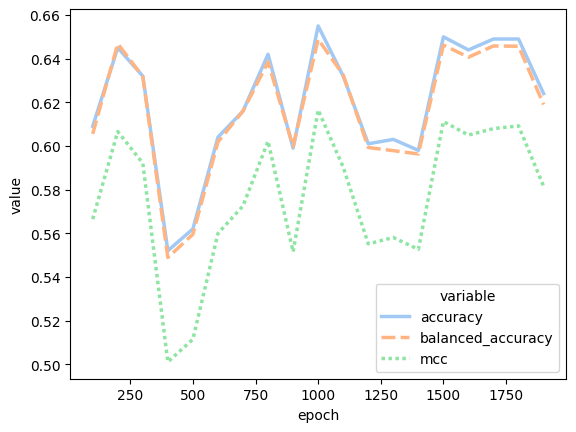

In [44]:
# sns.lineplot(data=pd.melt(vae_results, ['epoch']), x='epoch', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [11]:
synthesizer = CTGANSynthesizer(
    metadata, 
    epochs=1000
)

synthesizer.fit(intercepted_data)
synthetic_impersonation_data = synthesizer.sample(num_rows=1500)

In [12]:
synthetic_impersonation_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,170.5,175.6,152.4,169.1,171.6,13.0,166.5
1,rpi-8d,21.0,14.9,16.0,12.9,18.3,21.8,20.8
2,rpi-8b,20.5,24.7,2.8,210.5,219.8,217.8,19.6
3,odroid4,175.4,172.6,179.9,172.8,172.8,174.0,170.3
4,odroid2,166.6,188.4,6.2,166.3,167.9,166.2,167.4
...,...,...,...,...,...,...,...,...
1495,odroid4,167.0,175.4,175.4,172.0,172.4,174.2,172.9
1496,odroid4,169.0,165.9,187.1,174.8,172.7,173.4,172.8
1497,rpi-8d,14.0,20.1,860.8,393.3,21.0,24.3,20.7
1498,odroid4,172.3,173.4,180.8,171.0,170.1,174.9,170.3


In [13]:
# synthetic_impersonation_data.to_csv('gan_impersonator_testing.csv')

## Which devices are most vulnerable to this attack?

In [46]:
# devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
# for device in list(y_pred.unique()):
#     devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

# for pred, label in zip(list(y_pred), list(synthetic_impersonation_data['label'])):
#     if pred == label:
#         devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

# for device in list(y_pred.unique()):
#     devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_impersonation_data['label']).count(device)

# devices_fooled['accuracy'] *= 100

<Axes: xlabel='device', ylabel='accuracy'>

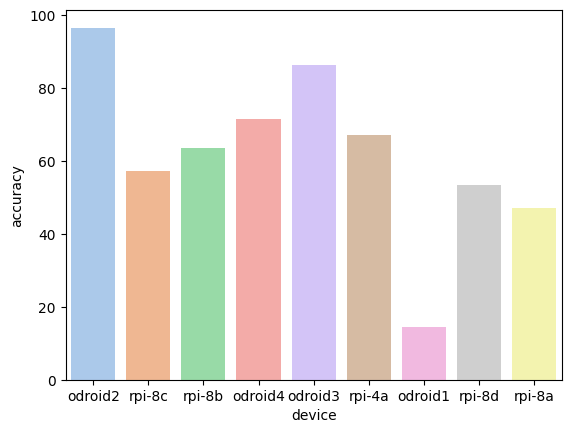

In [47]:
# sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Training an impersonation detection model

## Training Data

### Impersonator

In [8]:
# Let's say we use the same epoch as our adversary, and assume it's also the best epoch for our smaller dataset.
# However, we train the synthesizer on our train data ONLY.
# train and test data are used to train separate synthesizer models.
impersonator_training = pd.DataFrame()

synthesizer = CTGANSynthesizer(
    metadata, 
    epochs=1000
)

# Train the synthetic model using 75% of a train data. Holdout the rest for eval
synthesizer.fit(model_hardening_data.head(4500))
impersonator_training = synthesizer.sample(4500)

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\zac\miniconda3\envs\iot_gpu\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [9]:
impersonator_training

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,rpi-8a,12.9,233.4,213.6,12.2,14.3,219.1,220.3
1,odroid1,163.8,167.8,158.1,22.7,154.1,166.7,163.7
2,rpi-8c,15.5,19.0,22.8,216.4,15.9,55.3,78.8
3,odroid2,164.9,184.0,153.8,174.3,170.0,166.2,168.1
4,rpi-8a,221.9,246.4,215.0,216.6,9.3,231.2,220.1
...,...,...,...,...,...,...,...,...
4495,odroid2,167.0,174.7,152.0,175.2,176.4,172.0,170.0
4496,rpi-4a,28.4,1147.2,9.2,17.1,26.9,12.4,19.3
4497,odroid2,160.6,184.1,156.5,177.3,168.4,19.5,168.3
4498,rpi-4a,19.8,16.2,857.6,21.0,17.4,17.7,20.7


In [10]:
# impersonator_training.to_csv('gan_impersonator_training.csv')

In [20]:
impersonator_training['label'] = 'impersonator'

### Genuine

In [18]:
genuine_training = model_hardening_data.head(4500)
genuine_training['label'] = 'genuine'

<Axes: >

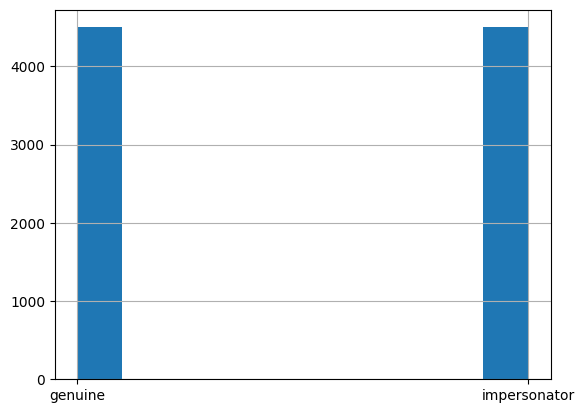

In [19]:
combined_training = pd.concat([genuine_training, impersonator_training])
combined_training = combined_training.sample(frac=1)
combined_training['label'].hist()

In [29]:
# combined_training.to_csv('gan_training.csv')

## Testing

### Impersonator

In [21]:
impersonator_testing = synthetic_impersonation_data.copy(deep=True)
impersonator_testing['label'] = 'impersonator'

### Genuine

In [22]:
genuine_testing = model_hardening_data.tail(1500).copy(deep=True)
genuine_testing['label'] = 'genuine'

<Axes: >

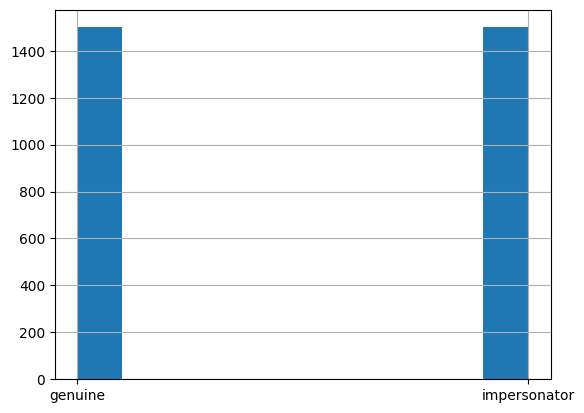

In [23]:
combined_testing = pd.concat([genuine_testing, impersonator_testing])
combined_testing['label'].hist()

In [30]:
# combined_testing.to_csv('gan_impersonation_testing.csv')

## Training the model

In [25]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

# How much data do we need to accurately detect an impersonator?
for data_amount in range(1000, 9000, 1000):
    print(f'Amount of data: {data_amount}')

    impersonation_detector = TabularPredictor(label='label').fit(combined_training[:data_amount], num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    
    y_pred = impersonation_detector.predict(combined_testing)
    y_pred_proba = impersonation_detector.predict_proba(combined_testing)
    results = impersonation_detector.evaluate(combined_testing)

    new_results = {'data_amount':data_amount, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250327_062342"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       48.75 GB / 63.72 GB (76.5%)
Disk Space Avail:   959.77 GB / 1906.98 GB (50.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250327_062342"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

Amount of data: 1000


	0.895	 = Validation score   (accuracy)
	1.86s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.92	 = Validation score   (accuracy)
	1.9s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.87	 = Validation score   (accuracy)
	0.35s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.885	 = Validation score   (accuracy)
	0.33s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.87	 = Validation score   (accuracy)
	0.31s	

Amount of data: 2000
[1000]	valid_set's binary_error: 0.1


	0.9075	 = Validation score   (accuracy)
	3.99s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9375	 = Validation score   (accuracy)
	2.39s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.885	 = Validation score   (accuracy)
	0.34s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.91	 = Validation score   (accuracy)
	0.32s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9025	 = Validation score   (accuracy)


...

	0.9543	 = Validation score   (accuracy)
	20.28s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9643	 = Validation score   (accuracy)
	2.63s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9414	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9457	 = Validation score   (accuracy)
	0.39s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9571	 = Validation score   (accurac

[1000]	valid_set's binary_error: 0.0342857


	0.9686	 = Validation score   (accuracy)
	16.97s	 = Training   runtime
	0.02s	 = Validation runtime
AutoGluon training complete, total runtime = 77.34s ... Best model: LightGBMLarge | Estimated inference throughput: 44522.8 rows/s (700 batch size)
Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (700 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250327_062839")
No path specified. Models will be saved in: "AutogluonModels\ag-20250327_062956"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform

Amount of data: 8000
[1000]	valid_set's binary_error: 0.05
[2000]	valid_set's binary_error: 0.03875


	0.9637	 = Validation score   (accuracy)
	12.3s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9675	 = Validation score   (accuracy)
	3.16s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9587	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.955	 = Validation score   (accuracy)
	0.42s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9637	 = Validation score   (accuracy

In [26]:
impersonation_detector.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,0.97125,accuracy,0.011965,17.447071,0.011965,17.447071,1,True,12
1,LightGBM,0.96750,accuracy,0.006610,3.164841,0.006610,3.164841,1,True,4
2,XGBoost,0.96625,accuracy,0.012247,1.956643,0.012247,1.956643,1,True,10
3,LightGBMXT,0.96375,accuracy,0.023713,12.300434,0.023713,12.300434,1,True,3
4,ExtraTreesEntr,0.96375,accuracy,0.042880,0.351691,0.042880,0.351691,1,True,8
5,ExtraTreesGini,0.96375,accuracy,0.043300,0.367723,0.043300,0.367723,1,True,7
6,RandomForestGini,0.95875,accuracy,0.043668,0.413085,0.043668,0.413085,1,True,5
7,RandomForestEntr,0.95500,accuracy,0.033288,0.415539,0.033288,0.415539,1,True,6
8,NeuralNetTorch,0.91250,accuracy,0.018692,72.797612,0.018692,72.797612,1,True,11
9,KNeighborsDist,0.86375,accuracy,0.019944,0.010380,0.019944,0.010380,1,True,2


In [27]:
results_df

,data_amount,accuracy,balanced_accuracy,mcc
0,1000,0.771667,0.771667,0.562790
1,2000,0.835000,0.835000,0.686722
2,3000,0.878333,0.878333,0.765964
3,4000,0.895667,0.895667,0.799281
4,5000,0.879667,0.879667,0.766813
5,6000,0.906333,0.906333,0.817155
6,7000,0.906667,0.906667,0.818861
7,8000,0.908333,0.908333,0.822678


# 2000 genuine/impersonator rows gives almost 90% acc

<Axes: xlabel='data_amount', ylabel='value'>

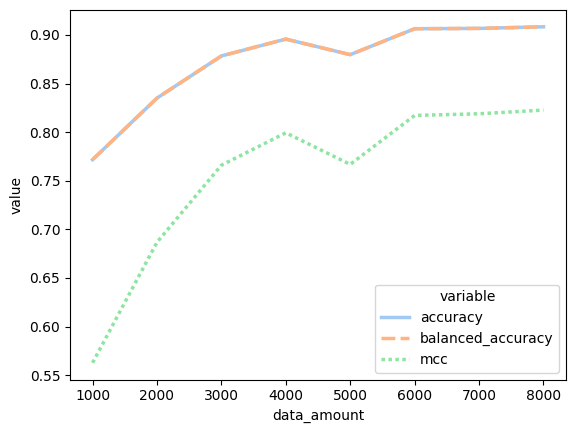

In [28]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)